# 本周作业：数据理解与预处理实践

本次作业的目标是让学生掌握 **数据理解** 和 **数据预处理** 相关的基本概念、统计描述、可视化方法以及使用 `sklearn` 进行数据预处理。


## **任务 1：属性及其类型（理论题）**

问题：  
1.解释 标称属性（Nominal）、序数属性（Ordinal）、间隔属性（Interval）、比率属性（Ratio） 的区别，并举例说明。  
2.下列数据属于哪种属性类型？（标称、序数、间隔、比率）  
    (a) 学生考试成绩（A, B, C, D）  
    (b) 温度（°C）  
    (c) 人的身高（cm）  
    (d) 邮政编码  
    (e) 电影评分（1星到5星）  

## **任务 2：数据的基本统计描述**

编写代码完成以下任务：  
1.加载鸢尾花数据集（Iris Dataset） 并创建 Pandas DataFrame。  
2.使用 describe() 输出 均值（Mean）、中位数（Median）、众数（Mode）、标准差（Std）、方差（Variance）、最大/最小值（Max/Min）。  
3.分别使用 Pandas 方法 单独计算并输出：  
    均值（df.mean()）
    中位数（df.median()）
    众数（df.mode()）
    标准差（df.std()）
    方差（df.var()）
    最大值/最小值（df.max() / df.min()）

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# 加载鸢尾花数据集
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 统计描述
print(df.describe())

# 计算各项统计量
print("均值:\n", df.mean())
print("中位数:\n", df.median())
print("众数:\n", df.mode())
print("标准差:\n", df.std())
print("方差:\n", df.var())
print("最大值:\n", df.max())
print("最小值:\n", df.min())

## 任务 3：数据可视化

编写代码完成以下任务：  
1.使用 直方图（Histogram） 显示每个特征的分布情况。  
2.使用 箱线图（Boxplot） 检测鸢尾花数据的异常值。  
3.使用 散点图（Scatter Plot） 观察 petal length (cm) 与 petal width (cm) 之间的关系。  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 直方图
df.hist(figsize=(8, 6))
plt.show()

# 箱线图
sns.boxplot(data=df)
plt.show()

# 散点图
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'])
plt.show()

## 任务 4：数据对象的相似性度量

编写代码计算以下相似性度量：  
1.欧氏距离（Euclidean Distance）  
2.曼哈顿距离（Manhattan Distance）  
3.余弦相似度（Cosine Similarity）  

In [ ]:
from scipy.spatial.distance import euclidean, cityblock
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

A = np.array([1, 2, 3])
B = np.array([4, 5, 6])

# 计算欧氏距离
print("欧氏距离:", euclidean(A, B))

# 计算曼哈顿距离
print("曼哈顿距离:", cityblock(A, B))

# 计算余弦相似度
cos_sim = cosine_similarity([A], [B])
print("余弦相似度:", cos_sim[0][0])

## 任务 5：数据预处理

5.1 加载数据：读取 CSV 文件，并创建 Pandas DataFrame。

In [1]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv("W3_Assignment_data.csv")

# 显示前几行数据
print(df.head())

   Employee_ID     Name   Age Department  Salary Joining_Date  \
0          101    Alice  25.0         HR  5000.0   2015-06-23   
1          102      Bob  30.0         IT  6000.0   2016-07-25   
2          103  Charlie   NaN         IT  7000.0   2018-03-19   
3          104    David  40.0    Finance  8000.0   2012-05-14   
4          105     Emma  35.0         HR  7500.0   2017-09-30   

   Performance_Score  Working_Hours Attrition  
0                3.0           40.0        No  
1                4.0           42.0       Yes  
2                5.0           38.0        No  
3                2.0           50.0       Yes  
4                NaN           45.0        No  


In [2]:
print(df)

   Employee_ID     Name   Age Department  Salary Joining_Date  \
0          101    Alice  25.0         HR  5000.0   2015-06-23   
1          102      Bob  30.0         IT  6000.0   2016-07-25   
2          103  Charlie   NaN         IT  7000.0   2018-03-19   
3          104    David  40.0    Finance  8000.0   2012-05-14   
4          105     Emma  35.0         HR  7500.0   2017-09-30   
5          106    Frank  28.0  Marketing     NaN   2019-11-01   
6          107    Grace  45.0    Finance  9000.0   2011-02-10   
7          108    Helen  32.0         IT  7200.0   2014-12-05   
8          109      Ivy   NaN  Marketing  6500.0   2018-06-15   
9          110     Jack  50.0    Finance     NaN   2013-08-20   

   Performance_Score  Working_Hours Attrition  
0                3.0           40.0        No  
1                4.0           42.0       Yes  
2                5.0           38.0        No  
3                2.0           50.0       Yes  
4                NaN           45.0        N

5.2数据清洗：  
处理缺失值（Age, Salary, Performance_Score）  
    
    缺失值的影响：
	1.导致分析结果偏差：如果数据集中存在大量缺失值，可能影响数据分布，导致分析偏差。
	2.影响机器学习模型训练：许多算法无法直接处理缺失值，必须填充或删除。

    常见处理方法：
	1.删除缺失值（适用于少量缺失值的情况）
	2.使用均值/中位数/众数填充
	3.使用插值或预测方法填充
处理重复数据（如 Employee_ID）  
处理异常值（如Salary、Working_Hours）  

In [3]:
from sklearn.impute import SimpleImputer

# 使用均值填充缺失值
imputer = SimpleImputer(strategy='mean')
df[['Age', 'Salary', 'Performance_Score', 'Working_Hours']] = imputer.fit_transform(df[['Age', 'Salary', 'Performance_Score', 'Working_Hours']])

# 确保缺失值已处理
print(df.isnull().sum())

Employee_ID          0
Name                 0
Age                  0
Department           0
Salary               0
Joining_Date         0
Performance_Score    0
Working_Hours        0
Attrition            0
dtype: int64


In [4]:
print(df)

   Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5000.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   
5          106    Frank  28.000  Marketing  7025.0   2019-11-01   
6          107    Grace  45.000    Finance  9000.0   2011-02-10   
7          108    Helen  32.000         IT  7200.0   2014-12-05   
8          109      Ivy  35.625  Marketing  6500.0   2018-06-15   
9          110     Jack  50.000    Finance  7025.0   2013-08-20   

   Performance_Score  Working_Hours Attrition  
0               3.00      40.000000        No  
1               4.00      42.000000       Yes  
2               5.00      38.000000        No  
3               2.00      50.000000       Yes  
4               3.75  

    重复数据的影响：
    1.影响统计分析：相同记录可能被计算多次，导致数据分析结果失真。
    2.影响模型训练：模型可能会学习到重复模式，导致过拟合。

In [6]:
duplicates = df[df.duplicated()]
print("重复行：\n", duplicates)

重复行：
 Empty DataFrame
Columns: [Employee_ID, Name, Age, Department, Salary, Joining_Date, Performance_Score, Working_Hours, Attrition]
Index: []


In [7]:
# 处理重复值
df = df.drop_duplicates()

In [15]:
print(df)

   Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5000.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   
5          106    Frank  28.000  Marketing  7025.0   2019-11-01   
6          107    Grace  45.000    Finance  9000.0   2011-02-10   
7          108    Helen  32.000         IT  7200.0   2014-12-05   
8          109      Ivy  35.625  Marketing  6500.0   2018-06-15   
9          110     Jack  50.000    Finance  7025.0   2013-08-20   

   Performance_Score  Working_Hours Attrition  Salary_Scaled  \
0               3.00      40.000000        No        0.00000   
1               4.00      42.000000       Yes        0.25000   
2               5.00      38.000000        No        0.50000   
3     

    异常值的影响：
    1.拉高/拉低数据分布，影响数据统计结果。
    2.误导模型训练，特别是对回归类模型影响较大。

In [11]:
# 异常值
import seaborn as sns
import matplotlib.pyplot as plt

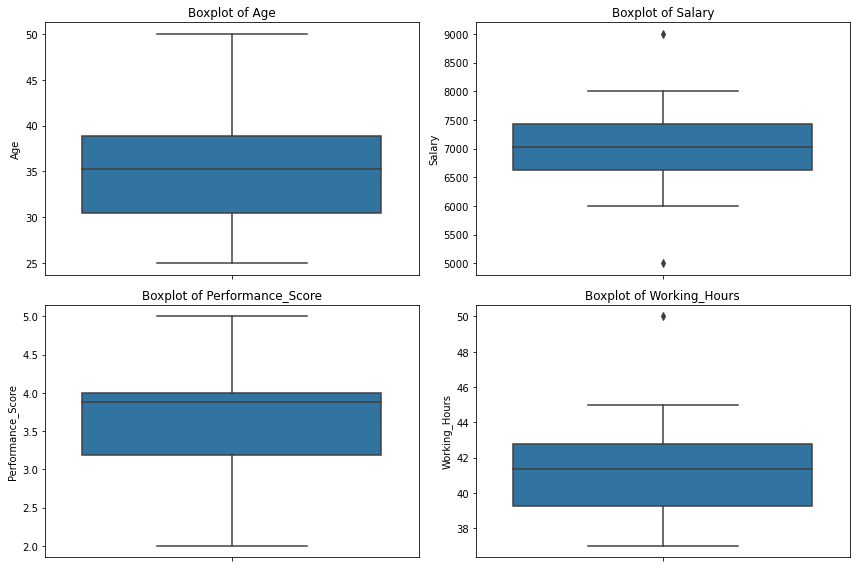

In [10]:
# 选取所有数值型列
numeric_cols = ['Age', 'Salary', 'Performance_Score', 'Working_Hours']

# 逐个绘制箱型图
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

5.3数据标准化：  
使用 Min-Max 归一化 处理 Salary  
适用于：数据范围固定，且不会有极端异常值时；深度学习和神经网络；保留数据的比例

使用 Z-Score 标准化 处理 Working_Hours  
适用于：数据存在极端值，或者需要对不同特征进行等权衡量时；线性模型（线性回归、SVM、PCA）；数据范围不固定

In [12]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler()：将数据缩放到 0-1 之间。
scaler = MinMaxScaler()
# scaler.fit_transform(df[['Salary']])：对 Salary 进行归一化，使得所有值在 [0,1] 之间。
df['Salary_Scaled'] = scaler.fit_transform(df[['Salary']])

In [13]:
from sklearn.preprocessing import StandardScaler

#StandardScaler()：将数据转换为 均值 0，标准差 1 的分布，适用于数据具有不同单位的情况。
scaler = StandardScaler()
#scaler.fit_transform(df[['Working_Hours']])：对 Working_Hours 进行标准化。
df['Working_Hours_Std'] = scaler.fit_transform(df[['Working_Hours']])

In [14]:
print(df)

   Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5000.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   
5          106    Frank  28.000  Marketing  7025.0   2019-11-01   
6          107    Grace  45.000    Finance  9000.0   2011-02-10   
7          108    Helen  32.000         IT  7200.0   2014-12-05   
8          109      Ivy  35.625  Marketing  6500.0   2018-06-15   
9          110     Jack  50.000    Finance  7025.0   2013-08-20   

   Performance_Score  Working_Hours Attrition  Salary_Scaled  \
0               3.00      40.000000        No        0.00000   
1               4.00      42.000000       Yes        0.25000   
2               5.00      38.000000        No        0.50000   
3     

5.4数据规约：  
使用 PCA 降维 处理 Salary 和 Working_Hours  
降维减少计算量，降低数据冗余，提高模型训练效率。
1. 线性降维方法：
    PCA（主成分分析）、
	LDA（线性判别分析，Linear Discriminant Analysis）、
	FA（因子分析，Factor Analysis）、
	ICA（独立成分分析，Independent Component Analysis）、
2. 非线性降维方法：
	t-SNE（t-分布邻域嵌入，t-Distributed Stochastic Neighbor Embedding）、
	UMAP（统一流形近似与投影，Uniform Manifold Approximation and Projection）、
	Isomap（等距映射）、
	LLE（局部线性嵌入，Locally Linear Embedding）、
3. 基于特征选择的降维：
	Filter 方法（如基于方差、皮尔逊相关系数）、
	Wrapper 方法（如基于递归特征消除 RFE）、
	Embedded 方法（如基于 Lasso 回归的特征选择）、

In [16]:
from sklearn.decomposition import PCA

# PCA(n_components=1)：使用主成分分析（PCA），将 Salary 和 Working_Hours 降维成一个新特征 Salary_PCA。
pca = PCA(n_components=1)
df['Salary_PCA'] = pca.fit_transform(df[['Salary', 'Working_Hours']])

print(df[['Salary_PCA']])

     Salary_PCA
0  2.025000e+03
1  1.024999e+03
2  2.500492e+01
3 -9.750103e+02
4 -4.750041e+02
5  3.594402e-03
6 -1.974997e+03
7 -1.750016e+02
8  5.250058e+02
9  9.577410e-18


In [17]:
print(df)

   Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5000.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   
5          106    Frank  28.000  Marketing  7025.0   2019-11-01   
6          107    Grace  45.000    Finance  9000.0   2011-02-10   
7          108    Helen  32.000         IT  7200.0   2014-12-05   
8          109      Ivy  35.625  Marketing  6500.0   2018-06-15   
9          110     Jack  50.000    Finance  7025.0   2013-08-20   

   Performance_Score  Working_Hours Attrition  Salary_Scaled  \
0               3.00      40.000000        No        0.00000   
1               4.00      42.000000       Yes        0.25000   
2               5.00      38.000000        No        0.50000   
3     

5.5数据变换：  
- 将类别变量转换为数值型数据，适用于机器学习模型训练  
- 对 Salary 进行 对数变换，使数据更加正态化  
- 使数据更符合正态分布，减少偏态（Skewness）

In [18]:
import numpy as np

# np.log(df['Salary'])：对 Salary 进行 对数变换，减少数据的偏态影响。
df['Salary_Log'] = np.log(df['Salary'])
print(df[['Salary', 'Salary_Log']])

   Salary  Salary_Log
0  5000.0    8.517193
1  6000.0    8.699515
2  7000.0    8.853665
3  8000.0    8.987197
4  7500.0    8.922658
5  7025.0    8.857230
6  9000.0    9.104980
7  7200.0    8.881836
8  6500.0    8.779557
9  7025.0    8.857230


5.6数据离散化：
- 使用 等宽分箱 方法对 Age 进行分箱（例如：青年、中年、老年）
- 连续变量转换为类别变量，适用于分类任务。

In [19]:
df['Age_Bins'] = pd.cut(df['Age'], bins=3, labels=['青年', '中年', '老年'])
print(df[['Age', 'Age_Bins']])

      Age Age_Bins
0  25.000       青年
1  30.000       青年
2  35.625       中年
3  40.000       中年
4  35.000       中年
5  28.000       青年
6  45.000       老年
7  32.000       青年
8  35.625       中年
9  50.000       老年


5.7数据编码：
使用 独热编码（One-Hot Encoding） 处理 Department  
使用 Label Encoding 处理 Attrition  

In [ ]:
# 独热编码 One-Hot Encoding
df = pd.get_dummies(df, columns=['Department'])

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Attrition_Label'] = label_encoder.fit_transform(df['Attrition'])

print(df.head())